# Mini-PVA Totalp – Multi-Day Analysis (Week 2/3)

**Site:** Totalp, Davos (N46.838°, E9.813°, 2480 m a.s.l.) | **Period:** October 2024 – March 2025  
**Group 1 focus:** Very steep ground inclinations (HN ≥ 20°)

This notebook extends the single-day analysis to the full winter measurement period. Key steps:
1. Load and combine 180 daily Mini-PVA CSV files
2. Data cleaning: timezone handling (DST), MN/RA validation, STC normalisation
3. Day-wise interpolation of environmental data (no overnight bridging)
4. Solar position calculation via pvlib
5. GHI variability index (2-minute rolling std)
6. Daily yield calculation via trapezoidal integration
7. Visualisations

---

## Data Cleaning Challenges

| Problem | Cause | Solution |
|---------|-------|----------|
| MN values > 1000 (e.g. 65516 → should be −20°) | Unsigned 16-bit integer overflow in measurement controller | Subtract 65536 |
| 8 rows with ambiguous timestamp (02:00→03:00 CEST→CET) | DST transition 27.10.2024 | `ambiguous='NaT'` → drop rows |
| MN = 0 (7936 rows) | Night/safe position of actuator | Drop (Pmpp ≈ 0, no yield) |
| Overnight interpolation would create false values | Standard time-interp bridges gaps across midnight | Day-wise interpolation function |
| Large files in Git repo | CSV files > 100 MB | `.gitignore` for `data/`, git `filter-branch` history rewrite |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import matplotlib.dates as mdates
import pvlib

### 1. Site Constants

In [2]:
LAT, LON, ALT = 46.838, 9.813, 2480   # latitude [°N], longitude [°E], altitude [m]
TZ = "Europe/Zurich"

# The 4 measurement channels used for analysis:
#   Ch 18: Front row, front side   Ch 22: Front row, back side
#   Ch  3: Back row,  front side   Ch  7: Back row,  back side
RELEVANT_CHANNELS = {
    18: "Front row – Front side",
    22: "Front row – Back side",
     3: "Back row – Front side",
     7: "Back row – Back side",
}
COLORS = {18: "tab:blue", 22: "tab:cyan", 3: "tab:red", 7: "tab:orange"}

### 2. Data Loading

In [3]:
# STC reference powers: one value per channel, used to normalise Pmpp → Pnominal
stc_powers = pd.read_csv('../data/raw/STC_Powers.csv', sep=';', decimal=',')

# Mini-PVA: one CSV per day → load all 180 files and concatenate into one DataFrame
files = sorted(glob.glob('../data/raw/mini_pva_daily/*.csv'))
print(f"Mini-PVA daily files found: {len(files)}")
minipva = pd.concat(
    [pd.read_csv(f, sep=';', decimal=',') for f in files],
    ignore_index=True
)

# Environmental data (GHI, DNI, zenith, air temperature) for the full period
env_data_full = pd.read_csv('../data/raw/environmental_data.csv', sep=';', decimal=',')

# Large installation data (normalised power for 6 module groups A–F)
largeinstallation_full = pd.read_csv(
    '../data/raw/largeInstallation_measurementData.csv', sep=';', decimal=','
)

print(minipva.info())
print(env_data_full.info())
print(largeinstallation_full.info())

Mini-PVA daily files found: 180


C:\Users\chaen\AppData\Local\Temp\ipykernel_32544\1651127884.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  minipva = pd.concat(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951999 entries, 0 to 951998
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID.Results  951999 non-null  float64
 1   mes_date    951999 non-null  object 
 2   ID.Modul    951999 non-null  object 
 3   channel     951999 non-null  object 
 4   U0          951999 non-null  float64
 5   Ik          951999 non-null  float64
 6   Pmpp        951999 non-null  float64
 7   FF          927520 non-null  float64
 8   Ghor        951999 non-null  object 
 9   Tluft       951999 non-null  object 
 10  RA          951999 non-null  object 
 11  MN          951999 non-null  object 
 12  HN          951999 non-null  object 
 13  Res         951999 non-null  object 
 14  mes_time    951999 non-null  object 
dtypes: float64(5), object(10)
memory usage: 108.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546561 entries, 0 to 1546560
Data columns (total 5 columns):
 # 

### 3. Mini-PVA Data Cleaning

In [4]:
# mes_date already contains full datetime — mes_time is redundant → drop it
minipva.drop(columns=['mes_time'], inplace=True)

# Parse datetime — explicit format avoids ambiguity warnings
minipva['mes_date'] = pd.to_datetime(
    minipva['mes_date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Convert configuration columns from object to numeric
minipva['channel'] = pd.to_numeric(minipva['channel'], errors='coerce').astype('Int64')
minipva['RA']      = pd.to_numeric(minipva['RA'],      errors='coerce')
minipva['MN']      = pd.to_numeric(minipva['MN'],      errors='coerce')
minipva['HN']      = pd.to_numeric(minipva['HN'],      errors='coerce')

# Tluft: stored as "15.1°C" → strip unit and convert to float
minipva['Tluft'] = (
    minipva['Tluft'].astype(str)
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

# Ghor: may use comma as decimal separator → normalise to dot
minipva['Ghor'] = pd.to_numeric(
    minipva['Ghor'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

n_failed = minipva['mes_date'].isna().sum()
if n_failed > 0:
    print(f"⚠  {n_failed} timestamps could not be parsed")

# Must sort by time BEFORE localising to avoid AmbiguousTimeError.
# ambiguous='NaT': rows in the DST gap (27.10.2024 02:00–03:00) → dropped.
minipva.sort_values('mes_date', inplace=True)
minipva.reset_index(drop=True, inplace=True)

minipva['mes_date'] = minipva['mes_date'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
n_ambiguous = minipva['mes_date'].isna().sum()
print(f"Ambiguous timestamps (DST transition): {n_ambiguous} rows → dropped")
minipva.dropna(subset=['mes_date'], inplace=True)

minipva.sort_values(['channel', 'mes_date'], inplace=True)
minipva.reset_index(drop=True, inplace=True)

# MN: unsigned 16-bit integer overflow (e.g. 65516 = −20° in signed int16)
overflow_mask = minipva['MN'] > 1000
minipva.loc[overflow_mask, 'MN'] = minipva.loc[overflow_mask, 'MN'] - 65536
print(f"MN overflow corrections: {overflow_mask.sum()} rows")

# Negative MN = homing/night position → drop
invalid_mn = minipva['MN'] < 0
print(f"Negative MN (homing/night position): {invalid_mn.sum()} rows → dropped")
minipva = minipva[~invalid_mn].copy()

# RA: hardware limits 115–719 mm per device documentation
invalid_ra = (minipva['RA'] < 115) | (minipva['RA'] > 719)
print(f"Invalid RA values (outside 115–719 mm): {invalid_ra.sum()} rows → dropped")
minipva = minipva[~invalid_ra].copy()

# MN = 0: safe/night position (Pmpp ≈ 0, no yield) → drop
invalid_mn0 = minipva['MN'] == 0
print(f"MN = 0 (safe/night position): {invalid_mn0.sum()} rows → dropped")
minipva = minipva[~invalid_mn0].copy()

minipva.reset_index(drop=True, inplace=True)

print(f"\nAfter cleaning: {len(minipva):,} rows")
print(f"  MN values: {sorted(minipva['MN'].dropna().unique())}")
print(f"  RA values: {sorted(minipva['RA'].dropna().unique())}")
print(f"  HN values: {sorted(minipva['HN'].dropna().unique())}")

# STC normalisation: guard prevents double-merging if cell is re-run
stc_powers['Channel'] = stc_powers['Channel'].astype(int)
if 'STC_Power_mW' not in minipva.columns:
    minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
    minipva.drop(columns=['Channel'], inplace=True)

minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']

print(f"\nSTC normalisation: {minipva['Pnominal'].isna().sum()} rows without STC value")
print(minipva[['channel', 'Pmpp', 'STC_Power_mW', 'Pnominal']].head(5))

Ambiguous timestamps (DST transition): 8 rows → dropped
MN overflow corrections: 7 rows
Negative MN (homing/night position): 7 rows → dropped
Invalid RA values (outside 115–719 mm): 0 rows → dropped
MN = 0 (safe/night position): 7936 rows → dropped

After cleaning: 944,048 rows
  MN values: [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
  RA values: [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
  HN values: [0, 10, 20, 30, 40]

STC normalisation: 0 rows without STC value
   channel      Pmpp  STC_Power_mW  Pnominal
0        1    1.6968       2643.35  0.000642
1        1   10.0936       2643.35  0.003818
2        1  236.0527       2643.35  0.089301
3        1  332.4423       2643.35  0.125766
4        1  694.7178       2643.35  0.262817


### 4. Environmental & Large Installation Cleaning

In [5]:
# Environmental data
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full['Timestamp'] = pd.to_datetime(env_data_full['Timestamp'], format='mixed')
env_data_full.sort_values('Timestamp', inplace=True)
env_data_full['Timestamp'] = env_data_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full.reset_index(drop=True, inplace=True)

print(f"Environmental data: {len(env_data_full):,} rows | "
      f"{env_data_full['Timestamp'].min()} → {env_data_full['Timestamp'].max()}")

# Large installation data
largeinstallation_full['Timestamp'] = pd.to_datetime(
    largeinstallation_full['Timestamp'], format='mixed'
)
largeinstallation_full.sort_values('Timestamp', inplace=True)
largeinstallation_full['Timestamp'] = largeinstallation_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
largeinstallation_full.dropna(subset=['Timestamp'], inplace=True)
largeinstallation_full.columns = [
    c.replace(' ', '_') for c in largeinstallation_full.columns
]
largeinstallation_full.reset_index(drop=True, inplace=True)

print(f"Large installation: {len(largeinstallation_full):,} rows | "
      f"{largeinstallation_full['Timestamp'].min()} → "
      f"{largeinstallation_full['Timestamp'].max()}")

Environmental data: 1,545,841 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00
Large installation: 1,545,481 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00


### 5. Day-wise Interpolation

Standard time-based interpolation would bridge overnight gaps, creating physically
meaningless values (e.g. interpolating GHI from 23:00 to 07:00).
Solution: interpolate only within each calendar day.

In [6]:
def interpolate_by_day(source_df, source_ts_col, target_timestamps):
    """
    Interpolate source_df onto target_timestamps using time-based linear
    interpolation, restricted to within each calendar day.

    Parameters
    ----------
    source_df : pd.DataFrame
        Source data with a timezone-aware datetime column.
    source_ts_col : str
        Name of the timestamp column in source_df.
    target_timestamps : pd.DatetimeIndex
        Target timestamps to interpolate to (Mini-PVA measurement times).

    Returns
    -------
    pd.DataFrame
        Interpolated values at target_timestamps. Rows with no source data
        on the same calendar day remain NaN.
    """
    data_cols = [c for c in source_df.columns if c != source_ts_col]
    result = pd.DataFrame(index=target_timestamps, columns=data_cols, dtype=float)
    result.index.name = source_ts_col

    target_dates = pd.Series(target_timestamps).dt.date.unique()

    for date in target_dates:
        day_targets = target_timestamps[
            pd.Series(target_timestamps).dt.date.values == date
        ]
        day_source = source_df[source_df[source_ts_col].dt.date == date].copy()

        if len(day_source) == 0 or len(day_targets) == 0:
            continue

        day_source = day_source.set_index(source_ts_col)
        day_source = day_source.groupby(level=0).mean()  # duplicate timestamps → mean

        combined_index = day_source.index.union(day_targets).sort_values()
        reindexed      = day_source.reindex(combined_index)
        interpolated   = reindexed.interpolate(method='time')
        result.loc[day_targets, data_cols] = (
            interpolated.loc[day_targets, data_cols].values
        )

    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass
    return result


# Target timestamps: all unique Mini-PVA measurement times (sorted)
target_ts = pd.DatetimeIndex(sorted(minipva['mes_date'].unique()))

env_interp = interpolate_by_day(env_data_full.copy(), 'Timestamp', target_ts)

largeinstallation_full_copy = largeinstallation_full.copy()
largeinstallation_full_copy.columns = [
    'Timestamp' if c == 'Timestamp' else c
    for c in largeinstallation_full_copy.columns
]
large_interp = interpolate_by_day(largeinstallation_full_copy, 'Timestamp', target_ts)

print(f"Interpolation complete:")
print(f"  Env:   {env_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")
print(f"  Large: {large_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")

combined = minipva.copy()
combined = combined.merge(env_interp,   left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')

# Flag rows where environmental data could not be interpolated (0.8% of rows)
combined['env_missing'] = combined['GHI'].isna()

print(f"\nCombined shape: {combined.shape}")
print(f"Missing environmental data: {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

Interpolation complete:
  Env:   936657 of 944048 timestamps
  Large: 936657 of 944048 timestamps

Combined shape: (944048, 34)
Missing environmental data: 7,391 rows (0.8%)


### 6. Solar Position (pvlib)

Solar position is calculated analytically from site coordinates and time.
`sun_up = True` (elevation > 0°) is used as a filter for yield integration —
only measurements during daylight are included.

In [7]:
location = pvlib.location.Location(
    latitude=LAT, longitude=LON, altitude=ALT, tz=TZ
)

solpos = location.get_solarposition(target_ts)

# Rename to avoid collision with the 'Zenith' column in environmental data
solpos_df = solpos[['zenith', 'azimuth', 'elevation']].rename(columns={
    'zenith':    'solar_zenith',
    'azimuth':   'solar_azimuth',
    'elevation': 'solar_elevation',
})
solpos_df['sun_up'] = solpos_df['solar_elevation'] > 0

combined = combined.merge(solpos_df, left_on='mes_date', right_index=True, how='left')

print(f"Solar position calculated:")
print(f"  Measurements with sun above horizon: {combined['sun_up'].sum():,} "
      f"({combined['sun_up'].mean()*100:.1f}%)")

Solar position calculated:
  Measurements with sun above horizon: 836,400 (88.6%)


### 7. GHI Variability Index

A 2-minute rolling standard deviation of GHI serves as a proxy for cloud variability.
High values indicate rapidly changing cloud cover; low values indicate clear or fully overcast sky.

In [8]:
env_var = env_data_full.set_index('Timestamp').copy()
env_var['GHI_std_2min'] = (
    env_var['GHI']
    .rolling('2min', min_periods=3)   # at least 3 samples (~30 s) required
    .std()
)

ghi_std_interp = interpolate_by_day(
    env_var[['GHI_std_2min']].reset_index().rename(columns={'index': 'Timestamp'}),
    'Timestamp', target_ts
)
combined = combined.merge(ghi_std_interp, left_on='mes_date', right_index=True, how='left')

print("GHI variability index calculated (2-min rolling std)")

GHI variability index calculated (2-min rolling std)


### 8. Yield Calculation

Daily yield [Wh/Wp] is computed by integrating Pnominal over time using the trapezoidal rule,
restricted to daylight hours (`sun_up = True`).

In [9]:
def calculate_daily_yield(df, channel, MN=None, RA=None, HN=None,
                           date_start=None, date_end=None):
    """
    Calculate daily yield [Wh/Wp] for a given channel and optional
    configuration filters. Integration: trapezoidal rule, daylight only.

    Parameters
    ----------
    df : pd.DataFrame
        Combined dataset.
    channel : int
        Channel number (e.g. 18 = front row, front side).
    MN, RA, HN : float or None
        Optional configuration filters.
    date_start, date_end : str or None
        Optional date range ('YYYY-MM-DD').

    Returns
    -------
    pd.DataFrame
        Columns: date, yield_Wh_Wp, sun_hours, n_measurements.
    """
    sub = df[df['channel'] == channel].copy()
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]

    sub = sub[sub['sun_up'] == True].copy()
    sub = sub.sort_values('mes_date')
    sub['date'] = sub['mes_date'].dt.date

    results = []
    for date, grp in sub.groupby('date'):
        grp   = grp.sort_values('mes_date')
        t_sec = grp['mes_date'].astype('int64') / 1e9   # Unix time [s]
        p     = grp['Pnominal'].values                   # normalised power [–]

        # Trapezoidal integration: (W/Wp × s) / 3600 = Wh/Wp
        yield_Wh_Wp = np.trapz(p, t_sec) / 3600
        sun_hours   = (t_sec.iloc[-1] - t_sec.iloc[0]) / 3600

        results.append({
            'date':           date,
            'yield_Wh_Wp':    yield_Wh_Wp,
            'sun_hours':      sun_hours,
            'n_measurements': len(grp),
        })

    return pd.DataFrame(results)


def period_yield(df, channel, MN=None, RA=None, HN=None,
                 date_start=None, date_end=None):
    """Sum daily yields over a period [Wh/Wp]."""
    daily = calculate_daily_yield(df, channel, MN, RA, HN, date_start, date_end)
    return daily['yield_Wh_Wp'].sum()


print("── Example: Yield for October 2024 ──────────────────────────────────────")
for ch, label in RELEVANT_CHANNELS.items():
    y = period_yield(combined, ch, date_start='2024-10-01', date_end='2024-10-31')
    print(f"  Ch {ch:2d} ({label}): {y:.3f} Wh/Wp")

── Example: Yield for October 2024 ──────────────────────────────────────
  Ch 18 (Front row – Front side): 92.035 Wh/Wp
  Ch 22 (Front row – Back side): 30.757 Wh/Wp
  Ch  3 (Back row – Front side): 85.601 Wh/Wp
  Ch  7 (Back row – Back side): 33.666 Wh/Wp


### 9. Helper Function

In [10]:
def filter_combined(df, channel=None, MN=None, RA=None, HN=None,
                    date_start=None, date_end=None, sun_up_only=True):
    """
    Filter the combined dataset by channel, configuration, and date range.

    Parameters
    ----------
    df : pd.DataFrame
        Combined dataset.
    channel : int or None
        Channel number filter.
    MN, RA, HN : float or None
        Configuration filters.
    date_start, date_end : str or None
        Date range filters ('YYYY-MM-DD').
    sun_up_only : bool
        If True (default), restrict to daylight measurements.

    Returns
    -------
    pd.DataFrame
        Filtered and sorted subset of df.
    """
    sub = df.copy()
    if channel    is not None: sub = sub[sub['channel'] == channel]
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]
    if sun_up_only:
        sub = sub[sub['sun_up'] == True]
    return sub.sort_values('mes_date')

### 10. Dataset Overview

In [11]:
print("── Dataset overview ──────────────────────────────────────────────────────")
print(f"Combined dataset:   {len(combined):>10,} rows")
print(f"Period:             {combined['mes_date'].min()} → {combined['mes_date'].max()}")
print(f"MN values:          {sorted(combined['MN'].dropna().unique())}")
print(f"RA values:          {sorted(combined['RA'].dropna().unique())}")
print(f"HN values:          {sorted(combined['HN'].dropna().unique())}")
print(f"Missing env. data:  {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
print(f"\nRelevant channels subset: {len(df_rel):,} rows")

── Dataset overview ──────────────────────────────────────────────────────
Combined dataset:      944,048 rows
Period:             2024-10-01 00:00:29+02:00 → 2025-03-31 23:44:58+02:00
MN values:          [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
RA values:          [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
HN values:          [0, 10, 20, 30, 40]
Missing env. data:  7,391 rows (0.8%)

Relevant channels subset: 747,783 rows


### 11. Visualisations

#### Plot 1 – Daily yield over the full measurement period

Shows the seasonal trend: yield drops from October toward December (shortest days,
lowest sun angles) and recovers toward March.

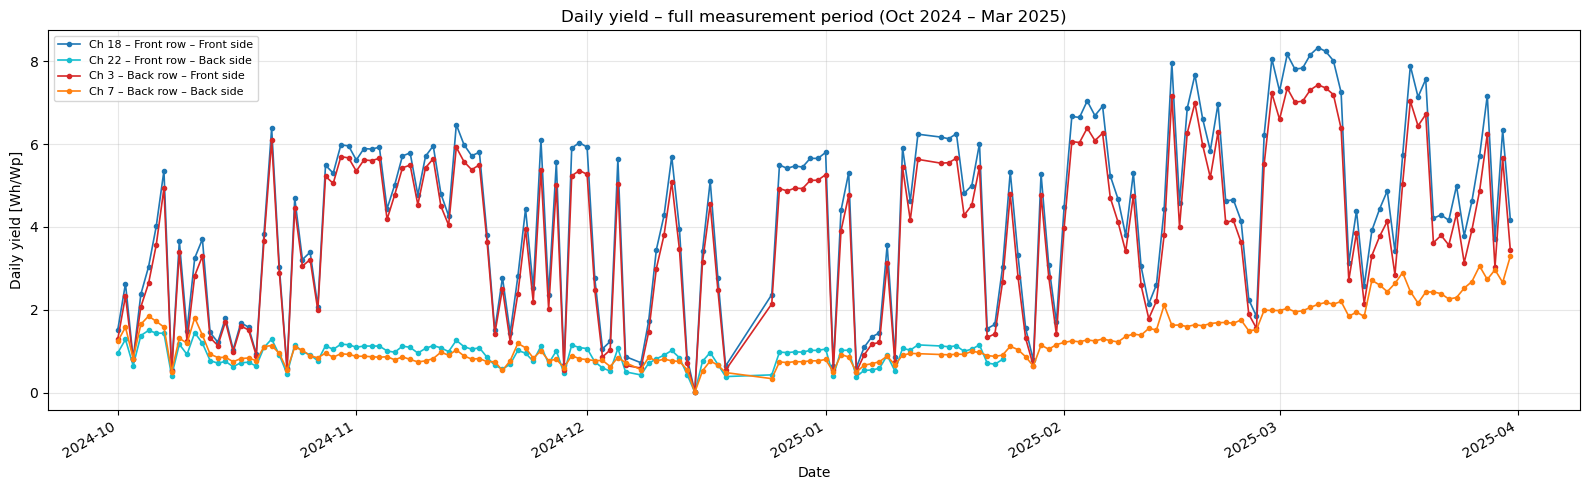

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))

for ch, label in RELEVANT_CHANNELS.items():
    daily = calculate_daily_yield(df_rel, ch)
    if len(daily) > 0:
        ax.plot(pd.to_datetime(daily['date']), daily['yield_Wh_Wp'],
                marker='o', ms=3, lw=1.2, color=COLORS[ch],
                label=f'Ch {ch} – {label}')

ax.set_ylabel('Daily yield [Wh/Wp]')
ax.set_xlabel('Date')
ax.set_title('Daily yield – full measurement period (Oct 2024 – Mar 2025)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 2 – Pnominal time series + GHI over several days

Multi-day view of normalised power for a fixed configuration.
Grey vertical lines mark calendar day boundaries.
The GHI panel shows how cloud cover drives day-to-day yield variation.

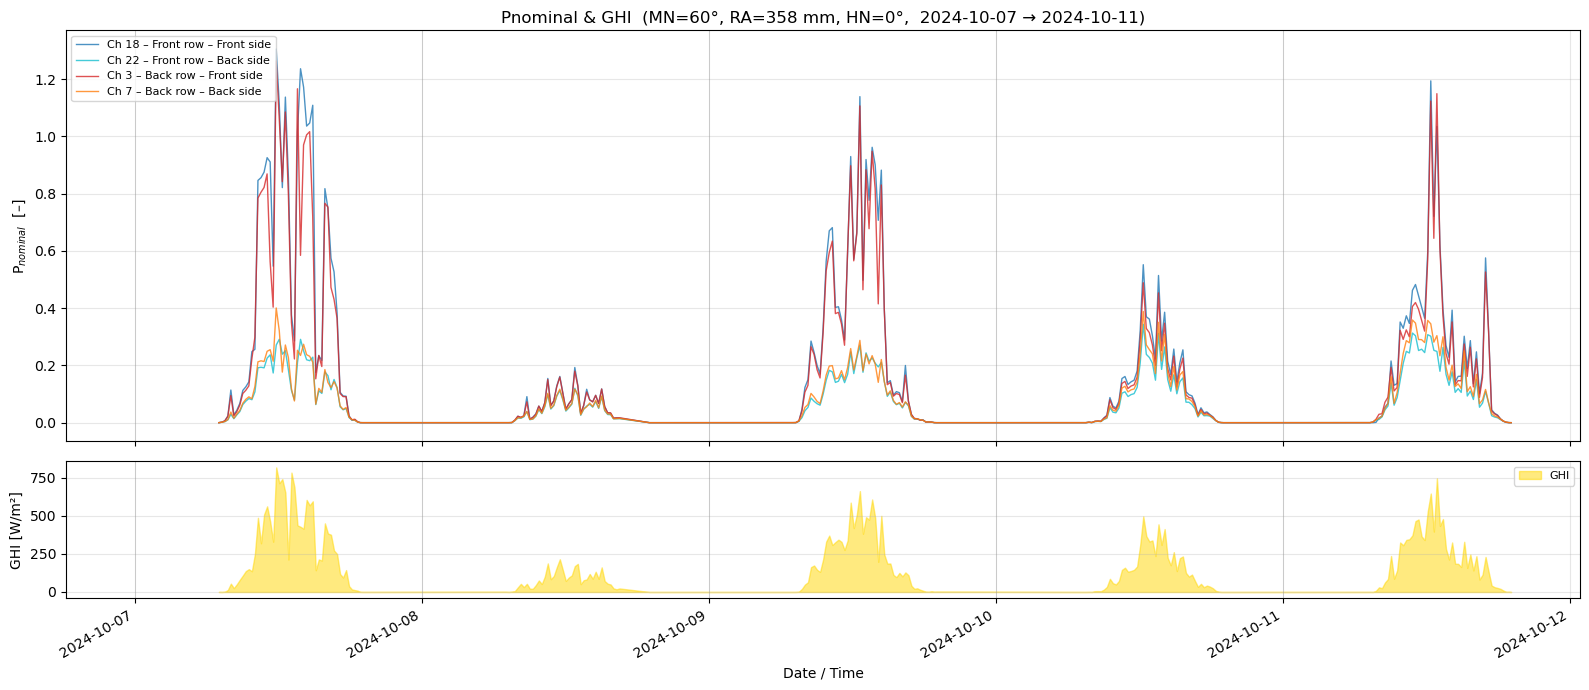

In [13]:
MN_SEL, RA_SEL, HN_SEL = 60, 358, 0
DATE_START, DATE_END    = '2024-10-07', '2024-10-11'

df_plot = filter_combined(df_rel, MN=MN_SEL, RA=RA_SEL, HN=HN_SEL,
                          date_start=DATE_START, date_end=DATE_END,
                          sun_up_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               lw=1.0, alpha=0.8, color=COLORS[ch],
               label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$  [–]')
ax_pv.set_title(f'Pnominal & GHI  (MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°,  '
                f'{DATE_START} → {DATE_END})')
ax_pv.legend(fontsize=8)
ax_pv.grid(True, alpha=0.3)

ghi_plot = df_plot[df_plot['channel'] == 18].sort_values('mes_date')
ax_ghi.fill_between(ghi_plot['mes_date'], ghi_plot['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI [W/m²]')
ax_ghi.set_xlabel('Date / Time')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

for date in pd.date_range(DATE_START, DATE_END, freq='D', tz=TZ):
    ax_pv.axvline(date,  color='grey', lw=0.5, alpha=0.4)
    ax_ghi.axvline(date, color='grey', lw=0.5, alpha=0.4)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 3 – Daily yield vs module tilt angle MN (boxplot)

Each boxplot shows the distribution of daily yields across all days for a given
module tilt angle. Front and back side channels are shown side by side for each row.

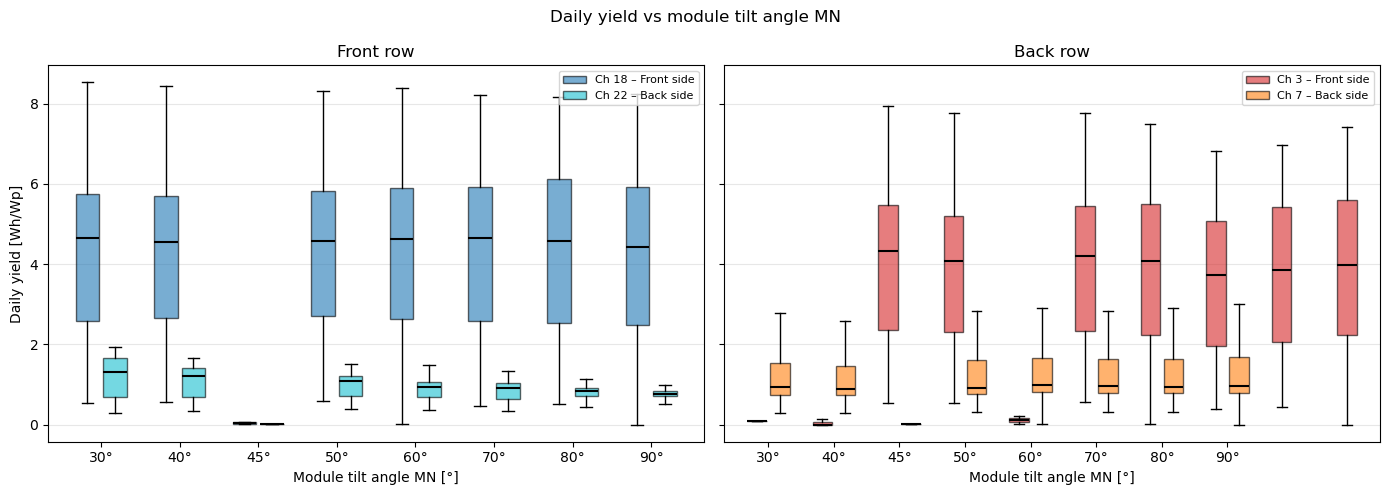

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, style, label_side in [
        (ch_front, dict(color=COLORS[ch_front]), 'Front side'),
        (ch_back,  dict(color=COLORS[ch_back]),  'Back side'),
    ]:
        mn_yields = {}
        for mn in sorted(df_rel['MN'].unique()):
            daily = calculate_daily_yield(df_rel, ch, MN=mn)
            if len(daily) > 0:
                mn_yields[mn] = daily['yield_Wh_Wp'].values

        mn_labels = sorted(mn_yields.keys())
        data      = [mn_yields[mn] for mn in mn_labels]
        # Offset front/back boxplots slightly so they don't overlap
        positions = [i + (0 if ch == ch_front else 0.35)
                     for i in range(len(mn_labels))]

        bp = ax.boxplot(data, positions=positions, widths=0.3,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=1.5))
        for patch in bp['boxes']:
            patch.set_facecolor(style['color'])
            patch.set_alpha(0.6)
        bp['boxes'][0].set_label(f'Ch {ch} – {label_side}')

    ax.set_xticks([i + 0.175 for i in range(len(mn_labels))])
    ax.set_xticklabels([f'{mn}°' for mn in mn_labels])
    ax.set_xlabel('Module tilt angle MN [°]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Daily yield [Wh/Wp]')
fig.suptitle('Daily yield vs module tilt angle MN', fontsize=12)
plt.tight_layout()
plt.show()

#### Plot 4 – Daily yield vs GHI variability (scatter)

Tests whether cloudy/variable days systematically produce lower yields.
Expected pattern: clear days (low std, high GHI) → high yield;
overcast days (low std, low GHI) → low yield.

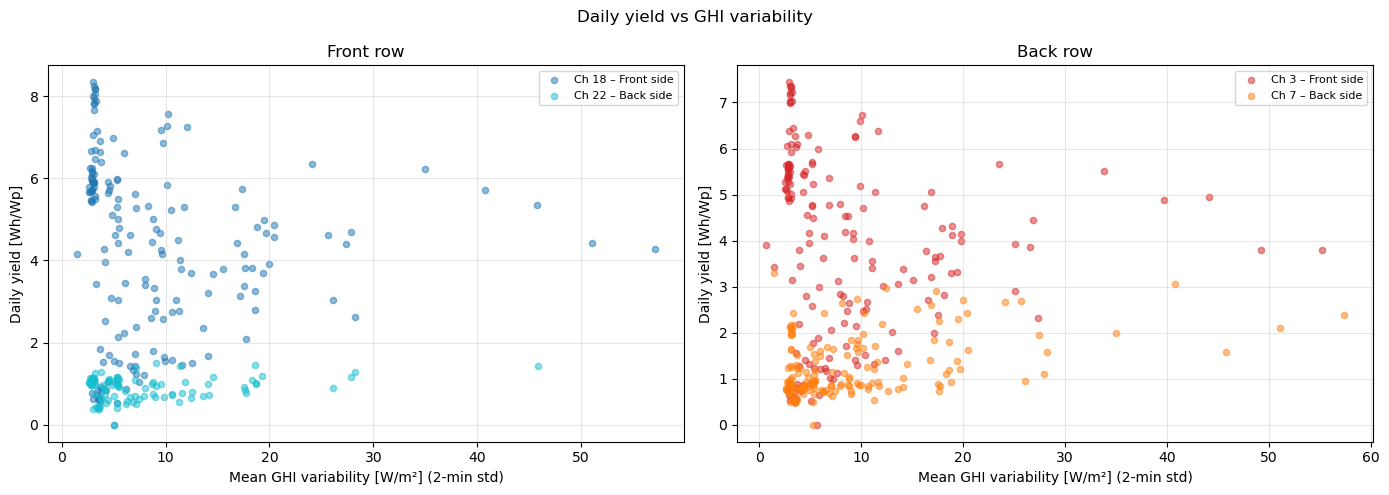

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, label_side in [(ch_front, 'Front side'), (ch_back, 'Back side')]:
        daily = calculate_daily_yield(df_rel, ch)
        if len(daily) == 0:
            continue

        # Mean GHI variability per day
        ghi_daily = (
            df_rel[df_rel['channel'] == ch]
            .assign(date=lambda x: x['mes_date'].dt.date)
            .groupby('date')['GHI_std_2min']
            .mean()
            .reset_index()
        )
        merged = daily.merge(ghi_daily, on='date', how='inner')

        ax.scatter(merged['GHI_std_2min'], merged['yield_Wh_Wp'],
                   alpha=0.5, s=20, color=COLORS[ch],
                   label=f'Ch {ch} – {label_side}')

    ax.set_xlabel('Mean GHI variability [W/m²] (2-min std)')
    ax.set_ylabel('Daily yield [Wh/Wp]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Daily yield vs GHI variability', fontsize=12)
plt.tight_layout()
plt.show()

#### Plot 5 – Solar position (elevation & azimuth)

Example day showing the calculated solar trajectory.
At this alpine site (N46.8°) in November, maximum elevation is only ~20° —
relevant for understanding why flatter module tilts are optimal in winter.

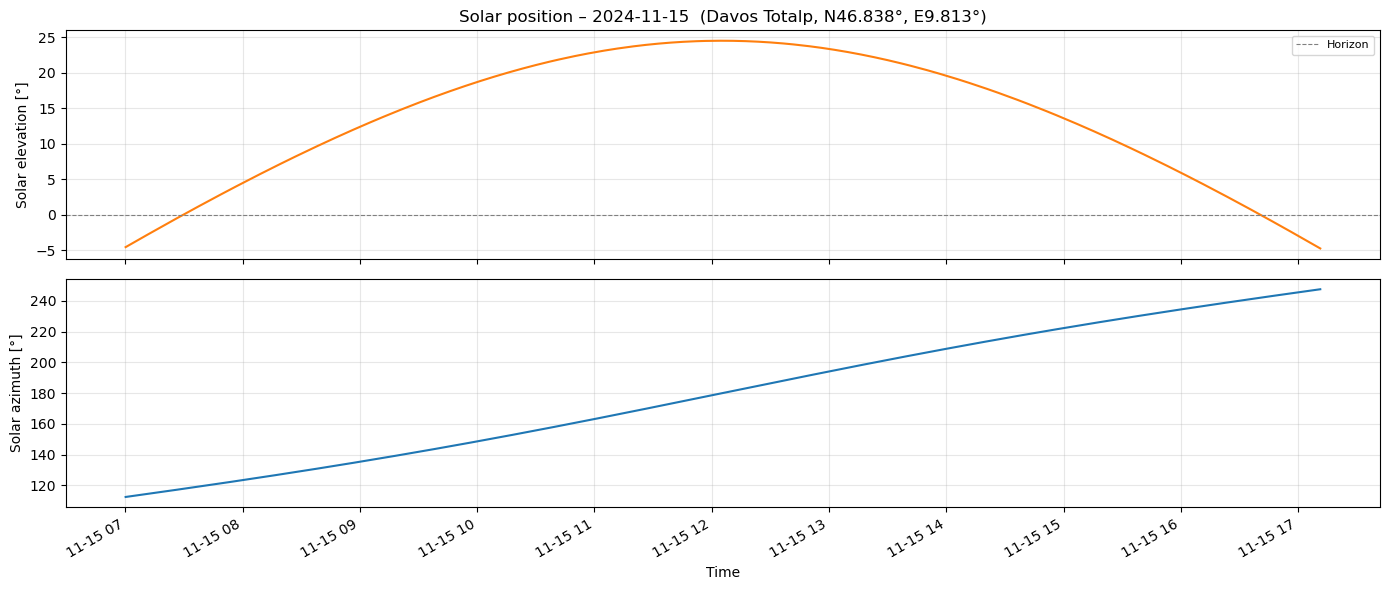

In [16]:
EXAMPLE_DATE = '2024-11-15'

sol_day = combined[
    (combined['mes_date'].dt.date == pd.Timestamp(EXAMPLE_DATE).date()) &
    (combined['channel'] == 18)   # any single channel — solar position is site-wide
].sort_values('mes_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax_el, ax_az = axes

ax_el.plot(sol_day['mes_date'], sol_day['solar_elevation'],
           color='tab:orange', lw=1.5)
ax_el.axhline(0, color='grey', lw=0.8, linestyle='--', label='Horizon')
ax_el.set_ylabel('Solar elevation [°]')
ax_el.set_title(f'Solar position – {EXAMPLE_DATE}  '
                f'(Davos Totalp, N{LAT}°, E{LON}°)')
ax_el.legend(fontsize=8)
ax_el.grid(True, alpha=0.3)

ax_az.plot(sol_day['mes_date'], sol_day['solar_azimuth'],
           color='tab:blue', lw=1.5)
ax_az.set_ylabel('Solar azimuth [°]')
ax_az.set_xlabel('Time')
ax_az.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()